
# LiDAR Exercise Solutions in Python

This notebook solves the seven exercises from the prompt. The workflow is:

1. Compute the emitted-to-received LiDAR power ratio using the single-scatterer LiDAR equation.
2. Formulate and implement a best straight-line fit as an orthogonal least-squares optimization problem.
3. Implement a line-circle intersection function.
4. Use the intersection function to simulate a 2D LiDAR scan of a cylindrical robot.
5. Add a wall behind the robot and simulate the combined robot-wall point cloud.
6. Fit a line to the wall cluster using the optimization problem from Exercise 2.
7. Move the robot to several positions and rerun the simulation.

The simulation is deliberately written as a readable, transparent 2D ray-casting model. It is not intended to replace a full LiDAR radiative-transfer simulator.


In [ ]:

import math
from dataclasses import dataclass
from typing import Iterable, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

np.set_printoptions(precision=4, suppress=True)



## Exercise 1 — LiDAR emitted/received power ratio

For one scatterer, the simplified single-scatterer LiDAR equation used here is

$
\frac{P_R}{P_T}
= \frac{\rho A_s D_r^2 \eta_{atm}\eta_{sys}}
       {R^4 \beta_t^2 \Omega},
$

where

- $(R)$ is range,
- $(\beta_t = \tan(\varphi))$ is the tangent of the beam divergence angle,
- $(D_r)$ is receiver diameter,
- $(A_s)$ is the effective scattering area,
- $(\rho)$ is reflectance,
- $(\Omega)$ is the backscatter cone solid angle,
- $(\eta_{atm})$ and $(\eta_{sys})$ are atmospheric and system efficiencies.

The formula follows by multiplying: beam footprint power density, target reflection, spreading back to the receiver, receiver aperture area, and transmission/system efficiencies.


In [ ]:

def lidar_power_ratio(
    range_m: float,
    divergence_rad: float,
    receiver_diameter_m: float,
    effective_area_m2: float,
    reflectance: float,
    scatter_solid_angle_sr: float,
    eta_atm: float,
    eta_sys: float,
) -> float:
    """Return P_R/P_T for the simplified single-scatterer LiDAR equation."""
    beta_t = math.tan(divergence_rad)
    numerator = reflectance * effective_area_m2 * receiver_diameter_m**2 * eta_atm * eta_sys
    denominator = range_m**4 * beta_t**2 * scatter_solid_angle_sr
    return numerator / denominator

params_ex1 = dict(
    range_m=150.0,
    divergence_rad=3e-3,
    receiver_diameter_m=0.15,
    effective_area_m2=0.17,
    reflectance=0.2,
    scatter_solid_angle_sr=0.5,
    eta_atm=0.9,
    eta_sys=0.9,
)

ratio_ex1 = lidar_power_ratio(**params_ex1)
print(f"P_R / P_T = {ratio_ex1:.3e}")
print("This is about 2.7e-7, matching the expected order of 2.6e-7.")


P_R / P_T = 2.720e-07
This is about 2.7e-7, matching the expected order of 2.6e-7.



## Exercise 2 — Optimization problem for best straight-line fit

Given points $(x_i,y_i)$, a robust line formulation is the normalized implicit line

$
a x + b y + c = 0, \qquad a^2+b^2=1.
$

The optimization problem is

$
\min_{a,b,c}\ \sum_{i=1}^{N} (a x_i + b y_i + c)^2
\quad \text{subject to}\quad a^2+b^2=1.
$

Because the normal vector $((a,b))$ has unit length, each residual is the signed perpendicular distance from a point to the line. This formulation also handles vertical lines without special cases.

A practical solution is total least squares/PCA:

1. Center the points by subtracting the centroid.
2. Compute the singular vectors of the centered point matrix.
3. The line normal is the singular vector associated with the smallest singular value.
4. Set $(c = -a\bar{x} - b\bar{y})$.


In [ ]:

@dataclass(frozen=True)
class LineFit:
    """Normalized implicit line fit: a*x + b*y + c = 0 with a^2 + b^2 = 1."""

    a: float
    b: float
    c: float
    centroid: np.ndarray
    rmse: float

    def signed_distances(self, points: np.ndarray) -> np.ndarray:
        points = np.asarray(points, dtype=float)
        return self.a * points[:, 0] + self.b * points[:, 1] + self.c

    def equation_string(self, digits: int = 4) -> str:
        return f"{self.a:.{digits}f} x + {self.b:.{digits}f} y + {self.c:.{digits}f} = 0"

    def slope_intercept(self) -> Optional[tuple[float, float]]:
        """Return y = m*x + q, or None for a vertical/near-vertical line."""
        if abs(self.b) < 1e-12:
            return None
        m = -self.a / self.b
        q = -self.c / self.b
        return m, q


def fit_line_tls(points: np.ndarray) -> LineFit:
    """Fit a 2D line using orthogonal least squares / total least squares."""
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError("points must have shape (N, 2)")
    if len(points) < 2:
        raise ValueError("at least two points are required")

    centroid = points.mean(axis=0)
    centered = points - centroid

    # Vt rows are the principal directions. The last row is the normal direction.
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    normal = vt[-1]
    normal = normal / np.linalg.norm(normal)

    # Use a consistent sign for prettier equations.
    if abs(normal[0]) >= abs(normal[1]):
        if normal[0] < 0:
            normal *= -1
    else:
        if normal[1] < 0:
            normal *= -1

    a, b = normal
    c = -np.dot(normal, centroid)
    residuals = points @ normal + c
    rmse = float(np.sqrt(np.mean(residuals**2)))
    return LineFit(float(a), float(b), float(c), centroid, rmse)


# Demonstration on noisy points sampled from a non-vertical line.
rng = np.random.default_rng(7)
x_demo = np.linspace(-2, 4, 40)
y_demo = 1.5 * x_demo - 0.4 + rng.normal(0, 0.15, size=x_demo.size)
points_demo = np.column_stack([x_demo, y_demo])
fit_demo = fit_line_tls(points_demo)

print("Example fitted line:", fit_demo.equation_string())
print(f"Orthogonal RMSE: {fit_demo.rmse:.4f} m")
print("Slope/intercept form:", fit_demo.slope_intercept())


Example fitted line: 0.8315 x + -0.5555 y + -0.2533 = 0
Orthogonal RMSE: 0.0674 m
Slope/intercept form: (1.4967560322377267, -0.45603380628774604)


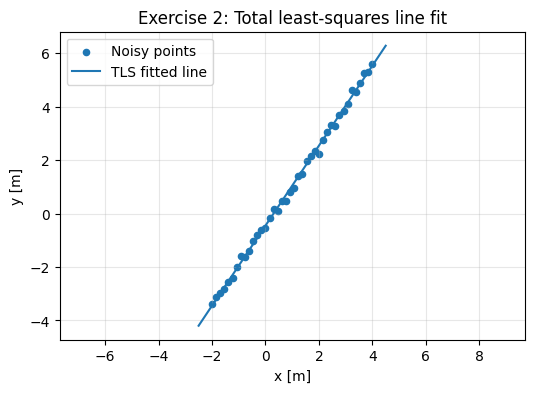

In [ ]:

plt.figure(figsize=(6, 4))
plt.scatter(points_demo[:, 0], points_demo[:, 1], s=20, label="Noisy points")

x_line = np.array([points_demo[:, 0].min() - 0.5, points_demo[:, 0].max() + 0.5])
if fit_demo.slope_intercept() is not None:
    m, q = fit_demo.slope_intercept()
    y_line = m * x_line + q
    plt.plot(x_line, y_line, label="TLS fitted line")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Exercise 2: Total least-squares line fit")
plt.legend()
plt.show()



## Exercise 3 — Line-circle intersection function

Represent the line through points $(p_1)$ and $(p_2)$ parametrically:

$
p(t)=p_1+t(p_2-p_1), \qquad -\infty<t<\infty.
$

A circle with center $(c)$ and radius $(r)$ satisfies

$
\|p(t)-c\|^2=r^2.
$

Substituting the parametric line gives a quadratic equation in $(t)$. The discriminant determines whether the line misses the circle, is tangent to it, or crosses it in two points.


In [ ]:

def line_circle_intersections(
    p1: Iterable[float],
    p2: Iterable[float],
    center: Iterable[float],
    radius: float,
    eps: float = 1e-12,
) -> np.ndarray:
    """Return the intersection points between an infinite 2D line and a circle.

    Parameters
    ----------
    p1, p2:
        Two distinct points defining the infinite line.
    center:
        Circle center as (x, y).
    radius:
        Circle radius. Must be non-negative.
    eps:
        Numerical tolerance for tangency.

    Returns
    -------
    numpy.ndarray
        Array with shape (0, 2), (1, 2), or (2, 2).
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    center = np.asarray(center, dtype=float)

    if radius < 0:
        raise ValueError("radius must be non-negative")

    direction = p2 - p1
    a = float(np.dot(direction, direction))
    if a <= eps:
        raise ValueError("p1 and p2 must be distinct points")

    shifted = p1 - center
    b = 2.0 * float(np.dot(shifted, direction))
    c = float(np.dot(shifted, shifted) - radius**2)
    discriminant = b**2 - 4.0 * a * c

    if discriminant < -eps:
        return np.empty((0, 2))

    if abs(discriminant) <= eps:
        t = -b / (2.0 * a)
        return (p1 + t * direction).reshape(1, 2)

    sqrt_disc = math.sqrt(discriminant)
    t_values = sorted(((-b - sqrt_disc) / (2.0 * a), (-b + sqrt_disc) / (2.0 * a)))
    return np.vstack([p1 + t * direction for t in t_values])


# Tests / examples.
circle_center = np.array([0.0, 0.0])
circle_radius = 1.0
examples = {
    "crossing": ((-2, 0), (2, 0)),
    "tangent": ((-2, 1), (2, 1)),
    "missing": ((-2, 2), (2, 2)),
}

for name, (p1, p2) in examples.items():
    intersections = line_circle_intersections(p1, p2, circle_center, circle_radius)
    print(f"{name:8s}: {len(intersections)} intersection(s) -> {intersections}")


crossing: 2 intersection(s) -> [[-1.  0.]
 [ 1.  0.]]
tangent : 1 intersection(s) -> [[0. 1.]]
missing : 0 intersection(s) -> []



## Ray-casting helpers for Exercises 4–7

For a LiDAR beam at angle $(\theta)$, the ray is

$
p(t)=o+t[\cos\theta,\sin\theta]^T, \qquad t\ge 0.
$

For every beam, the simulator checks intersections with each object and keeps the closest positive intersection. Range and bearing noise are added as

$
\tilde r = r + \nu_r, \qquad \tilde\theta = \theta + \nu_\theta,
$

with zero-mean Gaussian noise.


In [ ]:

def unit_vector(angle_rad: float) -> np.ndarray:
    return np.array([math.cos(angle_rad), math.sin(angle_rad)], dtype=float)


def cross_2d(a: np.ndarray, b: np.ndarray) -> float:
    return float(a[0] * b[1] - a[1] * b[0])


def ray_circle_intersection(
    origin: Iterable[float],
    angle_rad: float,
    center: Iterable[float],
    radius: float,
    eps: float = 1e-12,
) -> Optional[tuple[float, np.ndarray]]:
    """Return closest positive ray-circle intersection as (range, point), or None."""
    origin = np.asarray(origin, dtype=float)
    center = np.asarray(center, dtype=float)
    direction = unit_vector(angle_rad)

    shifted = origin - center
    b = 2.0 * float(np.dot(shifted, direction))
    c = float(np.dot(shifted, shifted) - radius**2)
    discriminant = b**2 - 4.0 * c  # a = dot(direction, direction) = 1

    if discriminant < -eps:
        return None

    if abs(discriminant) <= eps:
        t_values = [-b / 2.0]
    else:
        sqrt_disc = math.sqrt(discriminant)
        t_values = [(-b - sqrt_disc) / 2.0, (-b + sqrt_disc) / 2.0]

    positive_ranges = [t for t in t_values if t >= eps]
    if not positive_ranges:
        return None

    t_min = min(positive_ranges)
    return t_min, origin + t_min * direction


def ray_segment_intersection(
    origin: Iterable[float],
    angle_rad: float,
    seg_a: Iterable[float],
    seg_b: Iterable[float],
    eps: float = 1e-12,
) -> Optional[tuple[float, np.ndarray]]:
    """Return ray-line-segment intersection as (range, point), or None."""
    origin = np.asarray(origin, dtype=float)
    seg_a = np.asarray(seg_a, dtype=float)
    seg_b = np.asarray(seg_b, dtype=float)
    direction = unit_vector(angle_rad)
    segment_direction = seg_b - seg_a

    denominator = cross_2d(direction, segment_direction)
    if abs(denominator) <= eps:
        return None  # Parallel or collinear; not needed for this simulation.

    delta = seg_a - origin
    t = cross_2d(delta, segment_direction) / denominator
    s = cross_2d(delta, direction) / denominator

    if t >= eps and -eps <= s <= 1.0 + eps:
        return t, origin + t * direction
    return None


@dataclass(frozen=True)
class LidarScan:
    points: np.ndarray
    ideal_points: np.ndarray
    ranges: np.ndarray
    angles: np.ndarray
    labels: np.ndarray
    robot_center: np.ndarray
    robot_radius: float
    wall_segment: Optional[tuple[np.ndarray, np.ndarray]]
    lidar_origin: np.ndarray

    def cluster(self, label: str) -> np.ndarray:
        return self.points[self.labels == label]


def simulate_lidar_scan(
    robot_center: Iterable[float],
    robot_radius: float,
    wall_segment: Optional[tuple[Iterable[float], Iterable[float]]] = None,
    lidar_origin: Iterable[float] = (0.0, 0.0),
    angle_min_deg: float = -70.0,
    angle_max_deg: float = 70.0,
    n_beams: int = 421,
    max_range: float = 8.0,
    range_noise_std: float = 0.015,
    angle_noise_std: float = 8e-4,
    seed: int = 1,
) -> LidarScan:
    """Simulate a planar LiDAR scanning a circular robot and optionally a wall segment."""
    rng = np.random.default_rng(seed)
    origin = np.asarray(lidar_origin, dtype=float)
    robot_center = np.asarray(robot_center, dtype=float)

    wall_tuple = None
    if wall_segment is not None:
        wall_tuple = (np.asarray(wall_segment[0], dtype=float), np.asarray(wall_segment[1], dtype=float))

    beam_angles = np.deg2rad(np.linspace(angle_min_deg, angle_max_deg, n_beams))
    noisy_points: list[np.ndarray] = []
    ideal_points: list[np.ndarray] = []
    ranges: list[float] = []
    angles: list[float] = []
    labels: list[str] = []

    for angle in beam_angles:
        candidates: list[tuple[str, float, np.ndarray]] = []

        circle_hit = ray_circle_intersection(origin, angle, robot_center, robot_radius)
        if circle_hit is not None and circle_hit[0] <= max_range:
            candidates.append(("robot", circle_hit[0], circle_hit[1]))

        if wall_tuple is not None:
            wall_hit = ray_segment_intersection(origin, angle, wall_tuple[0], wall_tuple[1])
            if wall_hit is not None and wall_hit[0] <= max_range:
                candidates.append(("wall", wall_hit[0], wall_hit[1]))

        if not candidates:
            continue

        label, ideal_range, ideal_point = min(candidates, key=lambda item: item[1])

        noisy_range = max(0.0, ideal_range + rng.normal(0.0, range_noise_std))
        noisy_angle = angle + rng.normal(0.0, angle_noise_std)
        noisy_point = origin + noisy_range * unit_vector(noisy_angle)

        labels.append(label)
        ranges.append(noisy_range)
        angles.append(noisy_angle)
        ideal_points.append(ideal_point)
        noisy_points.append(noisy_point)

    return LidarScan(
        points=np.vstack(noisy_points) if noisy_points else np.empty((0, 2)),
        ideal_points=np.vstack(ideal_points) if ideal_points else np.empty((0, 2)),
        ranges=np.asarray(ranges),
        angles=np.asarray(angles),
        labels=np.asarray(labels, dtype=object),
        robot_center=robot_center,
        robot_radius=float(robot_radius),
        wall_segment=wall_tuple,
        lidar_origin=origin,
    )


def plot_scan(scan: LidarScan, title: str) -> None:
    """Plot a simulated LiDAR scan with the robot and wall geometry."""
    plt.figure(figsize=(7, 5))

    for label in ("wall", "robot"):
        pts = scan.cluster(label)
        if len(pts):
            plt.scatter(pts[:, 0], pts[:, 1], s=12, label=f"{label} returns")

    robot_patch = Circle(scan.robot_center, scan.robot_radius, fill=False, linewidth=2, label="robot body")
    plt.gca().add_patch(robot_patch)

    if scan.wall_segment is not None:
        wall_a, wall_b = scan.wall_segment
        plt.plot([wall_a[0], wall_b[0]], [wall_a[1], wall_b[1]], linewidth=2, label="wall")

    plt.scatter([scan.lidar_origin[0]], [scan.lidar_origin[1]], s=60, marker="x", label="LiDAR")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(title)
    plt.legend(loc="best")
    plt.show()



## Exercise 4 — Simulate LiDAR shooting at a cylindrical robot

The cylindrical robot is represented by a circle in the horizontal plane. Each ray is intersected with the circle, and range/bearing noise is added to the returned points.


Number of robot returns: 98


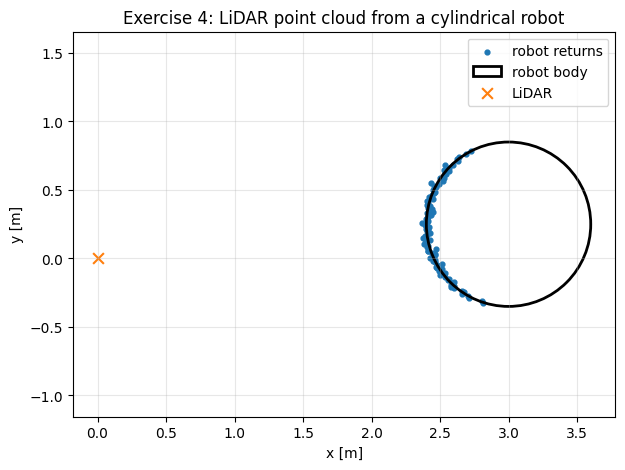

In [ ]:

scan_robot_only = simulate_lidar_scan(
    robot_center=(3.0, 0.25),
    robot_radius=0.60,
    wall_segment=None,
    angle_min_deg=-35,
    angle_max_deg=35,
    n_beams=301,
    range_noise_std=0.02,
    angle_noise_std=1.0e-3,
    seed=4,
)

print(f"Number of robot returns: {len(scan_robot_only.cluster('robot'))}")
plot_scan(scan_robot_only, "Exercise 4: LiDAR point cloud from a cylindrical robot")



## Exercise 5 — Robot in front of a wall

The wall is modeled as a finite line segment. The robot is between the LiDAR and the wall, so central beams hit the robot first and occlude part of the wall.


Robot returns: 133
Wall returns:  252


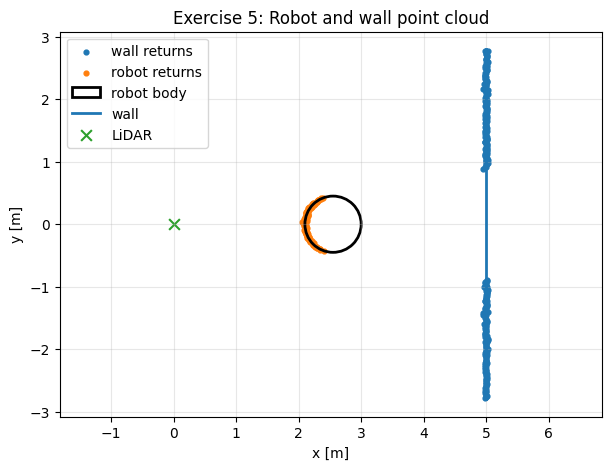

In [ ]:

wall = (np.array([5.0, -2.8]), np.array([5.0, 2.8]))

scan_robot_wall = simulate_lidar_scan(
    robot_center=(2.55, 0.0),
    robot_radius=0.45,
    wall_segment=wall,
    angle_min_deg=-38,
    angle_max_deg=38,
    n_beams=501,
    range_noise_std=0.015,
    angle_noise_std=8.0e-4,
    seed=10,
)

print(f"Robot returns: {len(scan_robot_wall.cluster('robot'))}")
print(f"Wall returns:  {len(scan_robot_wall.cluster('wall'))}")
plot_scan(scan_robot_wall, "Exercise 5: Robot and wall point cloud")



## Exercise 6 — Fit a line to the wall cluster

In this simulation we know which return was caused by the wall, so the wall cluster is selected by label. In real data, a clustering method such as nearest-neighbor grouping or DBSCAN would be used first. The selected wall points are fitted using the total least-squares line formulation from Exercise 2.


In [ ]:

wall_points = scan_robot_wall.cluster("wall")
wall_fit = fit_line_tls(wall_points)

print("Fitted wall line:", wall_fit.equation_string())
print(f"Orthogonal wall-fit RMSE: {wall_fit.rmse:.4f} m")

if wall_fit.slope_intercept() is None:
    estimated_x = -wall_fit.c / wall_fit.a
    print(f"The line is vertical/near-vertical: x ≈ {estimated_x:.4f} m")
else:
    m, q = wall_fit.slope_intercept()
    print(f"Slope/intercept: y = {m:.4f} x + {q:.4f}")


Fitted wall line: 1.0000 x + -0.0005 y + -4.9978 = 0
Orthogonal wall-fit RMSE: 0.0136 m
Slope/intercept: y = 1980.3615 x + -9897.5308


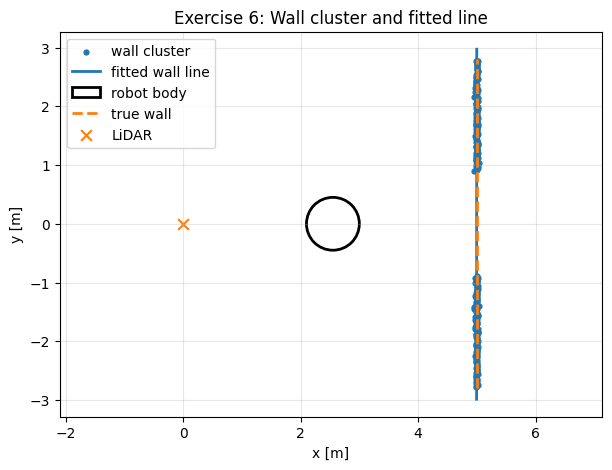

In [ ]:

plt.figure(figsize=(7, 5))
plt.scatter(wall_points[:, 0], wall_points[:, 1], s=12, label="wall cluster")

# Draw the fitted implicit line over the wall point y-range.
y_min, y_max = wall_points[:, 1].min() - 0.2, wall_points[:, 1].max() + 0.2
ys = np.linspace(y_min, y_max, 100)
if abs(wall_fit.a) > 1e-12:
    xs = -(wall_fit.b * ys + wall_fit.c) / wall_fit.a
    plt.plot(xs, ys, linewidth=2, label="fitted wall line")

# Show robot and true wall for context.
robot_patch = Circle(scan_robot_wall.robot_center, scan_robot_wall.robot_radius, fill=False, linewidth=2, label="robot body")
plt.gca().add_patch(robot_patch)
plt.plot([wall[0][0], wall[1][0]], [wall[0][1], wall[1][1]], linestyle="--", linewidth=2, label="true wall")
plt.scatter([0], [0], s=60, marker="x", label="LiDAR")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Exercise 6: Wall cluster and fitted line")
plt.legend(loc="best")
plt.show()



## Exercise 7 — Move the robot and rerun the simulation

The code below moves the robot to a few positions. The point clouds update automatically because each beam selects the closest intersection among the robot and wall.


Position 1: robot center=(2.15, -0.75), robot returns=150, wall returns=244, fitted wall x≈5.000 m, RMSE=0.015 m


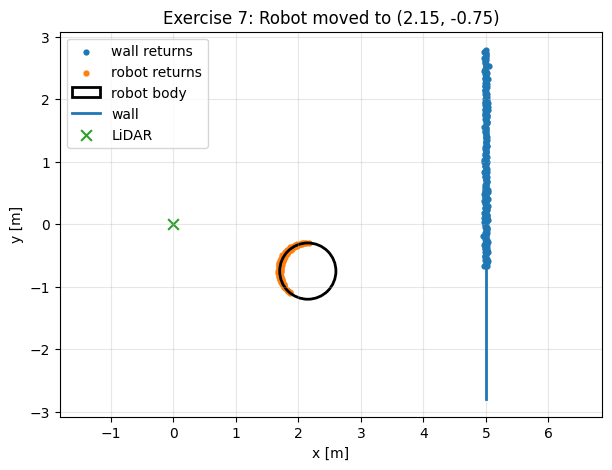

Position 2: robot center=(2.55, 0.0), robot returns=133, wall returns=252, fitted wall x≈4.998 m, RMSE=0.014 m


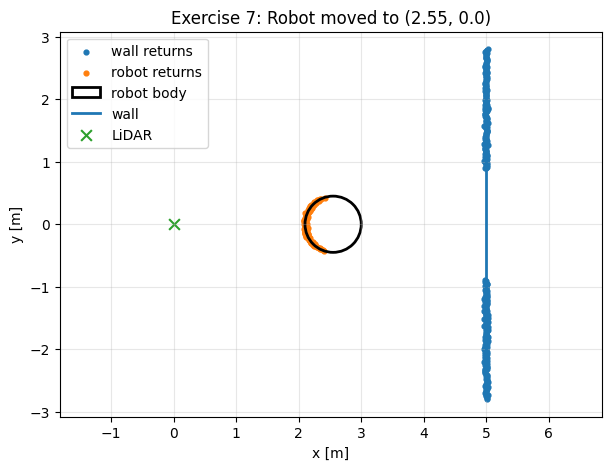

Position 3: robot center=(3.05, 0.75), robot returns=109, wall returns=276, fitted wall x≈4.999 m, RMSE=0.014 m


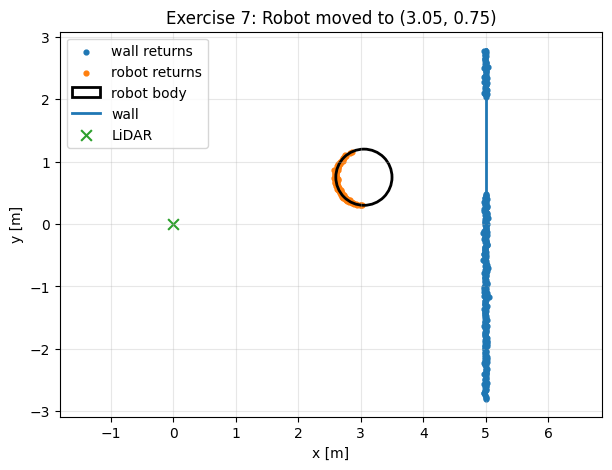

In [ ]:

robot_positions = [
    (2.15, -0.75),
    (2.55, 0.00),
    (3.05, 0.75),
]

summary_rows = []

for idx, position in enumerate(robot_positions, start=1):
    scan = simulate_lidar_scan(
        robot_center=position,
        robot_radius=0.45,
        wall_segment=wall,
        angle_min_deg=-38,
        angle_max_deg=38,
        n_beams=501,
        range_noise_std=0.015,
        angle_noise_std=8.0e-4,
        seed=100 + idx,
    )

    wall_cluster = scan.cluster("wall")
    robot_cluster = scan.cluster("robot")
    fit = fit_line_tls(wall_cluster)
    estimated_x = -fit.c / fit.a if abs(fit.a) > 1e-12 else np.nan

    summary_rows.append((idx, position, len(robot_cluster), len(wall_cluster), estimated_x, fit.rmse))
    print(
        f"Position {idx}: robot center={position}, "
        f"robot returns={len(robot_cluster)}, wall returns={len(wall_cluster)}, "
        f"fitted wall x≈{estimated_x:.3f} m, RMSE={fit.rmse:.3f} m"
    )
    plot_scan(scan, f"Exercise 7: Robot moved to {position}")


In [ ]:

print("\nSummary")
print("idx | robot_center | robot_returns | wall_returns | fitted_wall_x [m] | wall_RMSE [m]")
for row in summary_rows:
    idx, pos, n_robot, n_wall, x_est, rmse = row
    print(f"{idx:>3} | {pos!s:>14} | {n_robot:>13} | {n_wall:>12} | {x_est:>17.4f} | {rmse:>12.4f}")



Summary
idx | robot_center | robot_returns | wall_returns | fitted_wall_x [m] | wall_RMSE [m]
  1 |  (2.15, -0.75) |           150 |          244 |            5.0000 |       0.0147
  2 |    (2.55, 0.0) |           133 |          252 |            4.9978 |       0.0137
  3 |   (3.05, 0.75) |           109 |          276 |            4.9992 |       0.0144



## Conclusions

- The returned LiDAR power is a very small fraction of the emitted power: about $(2.7\times10^{-7})$ for the given airborne-surveying parameters. This is why receiver aperture, target reflectance, atmospheric transmission, and beam divergence strongly affect LiDAR detectability.
- The normalized implicit line model $(a x + b y + c = 0)$ is preferable to $(y=mx+b)$ for general geometric fitting because it handles vertical lines and minimizes perpendicular distances.
- The line-circle intersection function is the geometric core of the robot simulation: every LiDAR beam is a ray, and a return occurs at the closest positive intersection with the circular robot or wall.
- Adding a wall behind the robot naturally produces occlusion: beams that hit the robot first do not reach the wall.
- The wall cluster line fit recovers the vertical wall location close to the true $(x=5)$ m despite range and bearing noise.
- Moving the robot changes the robot point cluster and the occluded wall region, while the fitted wall line remains stable as long as enough wall points are visible.
